In [2]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_variance_groupby, compute_variance

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

In [129]:
dt=3
distance_to_coast_max = 20e3
alti_product_key='swot2km'


In [130]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = '',
        drifter_preprocess_param='',
        alti_product_key='swot250m',
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [ 
    update_dict(base_dic, {'alti_diff_method':'xarray_diff', 'ggd_var':'etac'}),
    base_dic, 
]

ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)

357737
12h_spectral_decomp_all_med_variational_10min_v1____swot250m_xarray_diff__etac__era5_rio0
364164
12h_spectral_decomp_all_med_variational_10min_v1____swot250m_fromduacsv__fromduacsv__era5_rio0
Identified SWOT and drifter outliers have been removed


In [144]:
def mean_df(df):
    return df.mean()
from scipy.stats import bootstrap
def compute_bootstrap_error(dff):
    # print(len(dff))
    #if len(dff) < 3:
    #return np.nan
    #else:
    data = (dff,)  # samples must be in a sequence
    return bootstrap(data, statistic=mean_df, n_resamples=n_resamples).standard_error


def compute_mean_square(ds, dirname = ('e', 'n'), compute_error = 'no', vars_errors=None):
    """ Compute closure stats
    ds : dataset containing terms values for all row_numbers
    dirname : directions of the reconstruction
    """
    d0, d1 = dirname[0], dirname[1]

    closure_vars_=closure_vars
    
    var = ['acc', 'cor', 'ggd', 'wd','sum']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']
    
    #if 'meancor'+dirname[0] in ds :
    #    print('ok')
    #    var += ['meancor', 'meanggd']
    #    VAR += ['meancor'.upper(), 'meanggd'.upper()]
    #    closure_vars_ = closure_vars +['MEANCOR*', 'MEANGGD*']
        
    dss = (ds[[v+d1 for v in var] + [v+d0 for v in var]]**2).rename({var[i]+d1 : VAR[i]+d1 for i in range(len(var))}).rename({var[i]+d0 : VAR[i]+d0 for i in range(len(var))})
    dss['sigma'+d0] = dss['ACC'+d0] + dss['COR'+d0] + dss['GGD'+d0] + dss['WD'+d0]
    dss['sigma'+d1] = dss['ACC'+d1] + dss['COR'+d1] + dss['GGD'+d1] + dss['WD'+d1]
    
    nb_coloc = len(ds.row_number)
    
    #Balanced and error
    for direction in [d0, d1]:
        for v in ['acc', 'cor', 'ggd', 'wd'] : 
            dss['B'+direction+'_'+v] = -((ds[v+direction]*ds['exc'+direction+'_'+v]))
            dss['E'+direction+'_'+v] = ((ds[v+direction]*ds['sum'+direction]))
            
    #pairs contributions
    for v in [v for v in ds if 'prod' in v]:
        dss[v.replace('prod', 'X')]=-2*ds[v]

    # Cyclo/anticyclo contribution
    for direction in [d0, d1]:
        dss['D'+direction+'_cyclo'] = -2 *(ds['acc'+direction]+ds['cor'+direction])*ds['ggd'+direction]
        dss['D'+direction+'_anticyclo'] = -2 *(ds['acc'+direction]+ds['ggd'+direction])*ds['cor'+direction]

    #Sum of both direction
    for v in closure_vars_ :
        dss[v.replace('*', '')] = dss[v.replace('*', dirname[0])] + dss[v.replace('*', dirname[1])]

    # Mean
    dsm = dss.mean('row_number')
    
    #STATISTICAL ERRORS
    #central limit
    if compute_error == 'centrallimit':
        dsme = (2*dss.std('row_number')/np.sqrt(nb_coloc)).rename({v:'er__'+v for v in list(dss.keys())})
        dsm = xr.merge([dsm, dsme])
        
    #bootstrap
    if compute_error == 'bootstrap':
        if vars_errors == None :
            vars_errors = [v.replace('*', dirname[0]) for v in closure_vars] + [v.replace('*', dirname[1]) for v in closure_vars] + [v.replace('*', '')for v in closure_vars]
        D = []
        for id_ in dss.id_comb : 
            dsme = xr.Dataset()
            dsme['id_comb']=id_
            dsme = dsme.set_coords('id_comb').expand_dims('id_comb')
            for v in vars_errors :
                er = compute_bootstrap_error(dss.sel(id_comb=id_)[v].dropna('row_number'))
                print(er)
                dsme[v] = ('id_comb', [er])
            D.append(dsme)
        dsme = xr.concat(D, dim='id_comb').rename({v:'er__'+v for v in vars_errors})
        dsm = xr.merge([dsm, dsme])
    
    #ATTRS    
    dsm.attrs['error_method'] = compute_error
    dsm = assign_attrs(dsm, list(dirname) + [''])


    return dsm
from diagnosis import closure_vars, assign_attrs, closure_vars



## Compare central limit VS bootstrap : can we deduce a degree of Freedom ?

In [145]:
DS_ = ds0.isel(row_number=slice(0, 50000))

In [ ]:
%%time
n_resamples=9999
dssb = compute_mean_square(DS_, compute_error = 'bootstrap', vars_errors = ['ACCe'])
dssb['method'] = 'bootstrap'
dssb = dssb.set_coords('method').expand_dims('method')

1.4332315538169561e-12


In [6]:
dssc = compute_mean_square(DS_, compute_error = 'centrallimit')
dssc['method'] = 'central_limit'
dssc = dssc.set_coords('method').expand_dims('method')

In [9]:
%%time
n_resamples=9999
dssb = compute_mean_square(DS_, compute_error = 'bootstrap')
dssb['method'] = 'bootstrap'
dssb = dssb.set_coords('method').expand_dims('method')

1.4332315538169561e-12
1.3553188961668066e-12
CPU times: user 47.3 s, sys: 51.4 s, total: 1min 38s
Wall time: 1min 38s


In [10]:
dssc

<xarray.Dataset> Size: 3kB
Dimensions:           (id_comb: 2, method: 1)
Coordinates:
  * id_comb           (id_comb) <U94 752B '12h_spectral_decomp_all_med_variat...
  * method            (method) <U13 52B 'central_limit'
Data variables: (12/132)
    ACCn              (method, id_comb) float64 16B 1.179e-10 1.207e-10
    CORn              (method, id_comb) float64 16B 2.624e-10 2.64e-10
    GGDn              (method, id_comb) float64 16B 1.459e-07 4.06e-10
    WDn               (method, id_comb) float64 16B 3.666e-11 3.419e-11
    Sn                (method, id_comb) float64 16B 1.459e-07 3.134e-10
    ACCe              (method, id_comb) float64 16B 1.15e-10 1.191e-10
    ...                ...
    er__X_acc_wd      (method, id_comb) float64 16B 4.376e-12 4.205e-12
    er__X_cor_ggd     (method, id_comb) float64 16B 2.076e-10 1.181e-11
    er__X_cor_wd      (method, id_comb) float64 16B 1.105e-11 1.066e-11
    er__X_ggd_wd      (method, id_comb) float64 16B 2.916e-10 9.112e-12
    er__D_cyclo       (method, id_comb) float64 16B 1.968e-10 1.116e-11
    er__D_anticyclo   (method, id_comb) float64 16B 2.076e-10 1.442e-11
Attributes:
    error_method:  centrallimit

In [120]:
c = dssc.isel(id_comb =0)[[v for v in dssc if 'er__' in v]].to_dataframe()
b = dssb.isel(id_comb =0)[[v for v in dssc  if 'er__' in v]].to_dataframe()*2 #CHECK CONFIDENCE INTERVAL

er = pd.concat([c,b]).iloc[:, :-1]

er.loc['ratio',:] = er.loc['bootstrap',:]/er.loc['central_limit',:]
er.loc['diff_ratio',:] = (er.loc['central_limit',:]-er.loc['bootstrap',:])/ er.loc['central_limit',:]
er

,er__ACCn,er__CORn,er__GGDn,er__WDn,er__Sn,er__ACCe,er__CORe,er__GGDe,er__WDe,er__Se,...,er__E_ggd,er__E_wd,er__X_acc_cor,er__X_acc_ggd,er__X_acc_wd,er__X_cor_ggd,er__X_cor_wd,er__X_ggd_wd,er__D_cyclo,er__D_anticyclo
method,,,,,,,,,,,,,,,,,,,,,
central_limit,8.763670e-12,1.546907e-11,6.594899e-09,2.360187e-12,6.593841e-09,9.574485e-12,7.245706e-12,6.351641e-09,1.397969e-12,6.312149e-09,...,9.496052e-09,1.165909e-10,2.414443e-11,5.040224e-10,9.053088e-12,6.271748e-10,1.143118e-11,2.327147e-10,4.886595e-10,6.320669e-10
bootstrap,8.676033e-12,1.544983e-11,6.607538e-09,2.391769e-12,6.638643e-09,9.573789e-12,7.254629e-12,6.340105e-09,1.404153e-12,6.310768e-09,...,9.441655e-09,1.175577e-10,2.403429e-11,5.047786e-10,9.074276e-12,6.355136e-10,1.153552e-11,2.309713e-10,4.907113e-10,6.324328e-10
ratio,9.899999e-01,9.987560e-01,1.001917e+00,1.013381e+00,1.006795e+00,9.999272e-01,1.001231e+00,9.981838e-01,1.004424e+00,9.997813e-01,...,9.942716e-01,1.008292e+00,9.954386e-01,1.001500e+00,1.002340e+00,1.013296e+00,1.009128e+00,9.925084e-01,1.004199e+00,1.000579e+00
diff_ratio,1.000009e-02,1.244049e-03,-1.916516e-03,-1.338117e-02,-6.794555e-03,7.276259e-05,-1.231434e-03,1.816155e-03,-4.423704e-03,2.187246e-04,...,5.728390e-03,-8.291988e-03,4.561438e-03,-1.500480e-03,-2.340430e-03,-1.329588e-02,-9.127608e-03,7.491604e-03,-4.198786e-03,-5.788682e-04


In [121]:
er.T.mean()

method
central_limit    1.510841e-09
bootstrap        1.510033e-09
ratio            1.001715e+00
diff_ratio      -1.715076e-03
dtype: float64

# Test synthetic

In [179]:
std = 0.5
n = int(1e3)
a = np.random.normal(scale = std, size = n)
#a = np.random.laplace(scale = std, size = n)

ND = 10
b_ = np.random.normal(scale = std, size = int(n/ND))
#b_ = np.random.laplace(scale = std, size = int(n/ND))
#b = np.sort(np.concatenate([b_]*ND))
b = np.concatenate([b_]*ND)

b.std()

0.49375313362086953

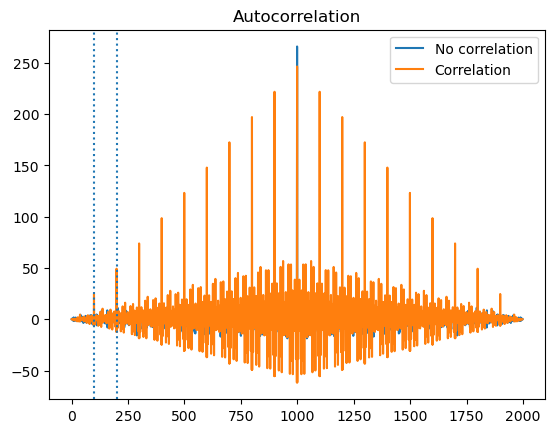

In [180]:
plt.plot(np.arange(2*n-1), np.correlate(a, a, 'full'), zorder=1, label='No correlation')
plt.plot(np.arange(2*n-1), np.correlate(b, b, 'full'), zorder=2, label='Correlation')
plt.axvline(n/ND, ls=':')
plt.axvline(2*n/ND, ls=':')
plt.title('Autocorrelation')
plt.legend()

In [183]:
def mean_df(df):
    return df.mean()
from scipy.stats import bootstrap

b_kwargs = dict(n_resamples=9999, method = 'basic')
stda = bootstrap((a,), statistic=mean_df, **b_kwargs).standard_error
stdb = bootstrap((b,), statistic=mean_df, **b_kwargs).standard_error
intera = bootstrap((a,), statistic=mean_df, **b_kwargs).confidence_interval
interb = bootstrap((b,), statistic=mean_df, **b_kwargs).confidence_interval


dfinter = pd.DataFrame()
dfinter['method'] = ['central_limit_uncorrelated', 'boot_strap_uncorrelated_n', 'central_limit_correlated_n', 'bootstrap_correlated', 'central_limit_correlated_adapted_degree_of_freedom']
dfinter['low'] = [a.mean() - 2*std/np.sqrt(n), intera.low, b.mean() - 2*std/np.sqrt(n), interb.low, b.mean() - 2*std/np.sqrt(n/ND)]
dfinter['high'] = [a.mean() + 2*std/np.sqrt(n), intera.high, b.mean() + 2*std/np.sqrt(n), interb.high, b.mean() + 2*std/np.sqrt(n/ND)]
dfinter['std_error'] = [std/np.sqrt(n), stda, std/np.sqrt(n), stdb, std/np.sqrt(n/ND)]
dfinter = dfinter.set_index('method')
#print(intera, interb)
#print('central limit degree of freedom = n', (a.mean() - 2*std/np.sqrt(n), a.mean() + 2*std/np.sqrt(n)), (b.mean() - 2*std/np.sqrt(n), b.mean() + 2*std/np.sqrt(n)))
#print('central limit with adapted degree of freedom = n',  (b.mean() - 2*std/np.sqrt(n/ND), b.mean() + 2*std/np.sqrt(n/ND)))

In [184]:
dfinter

,low,high,std_error
method,,,
central_limit_uncorrelated,-0.044592,0.018653,0.015811
boot_strap_uncorrelated_n,-0.044557,0.018889,0.016223
central_limit_correlated_n,-0.083807,-0.020561,0.015811
bootstrap_correlated,-0.082096,-0.021978,0.015629
central_limit_correlated_adapted_degree_of_freedom,-0.152184,0.047816,0.050000
